# FraudGuard - Transaction Fraud Intelligence
## Notebook 1 - Exploratory Data Analysis

### PACE: Plan

**Problem Statement:**
Payment fraud costs the global banking industry billions annually, with card-not-present fraud growing fastest as digital transactions scale. For a retail bank operating at scale, the challenge is balancing two asymmetric costs: financial loss from undetected fraud, and customer relationship damage from incorrectly blocking legitimate transactions. FraudGuard delivers a machine learning-powered transaction scoring tool that minimises both false negatives and false positive simultaneously. 

**Stakeholders**
- Risk and Compliance Leader - fraud risk exposure and board reporting
- Fraud Operations Analyst - alert prioritisation and investigation
- Risk Reporting & Governance - standardised audit-ready reporting
- Customer Experience Team - real-time visibility of blocked transactions

**Success Metrics:**
- Monthly fraud loss prevented ($) vs baseline
- False positive rate - legitimate transactions blocked (%)
- Mean time to investigate per alert (minutes)
- Net fraud loss reduction vs pre-deployment baseline (%)
- Fraud-Friction Ratio - fraudulent transactions blocked per legitimate transaction declined

In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [9]:
# Load transaction data - sample first

df_trans = pd.read_csv('../data/train_transaction.csv', nrows = 50000)

# Load identity data - full file (smaller)
df_identity = pd.read_csv('../data/train_identity.csv')

print("Transaction data:")
print(f" Shape: {df_trans.shape}")
print(f" Columns: {df_trans.shape[1]}")

# Merge on TransactionID

df = df_trans.merge(df_identity, on='TransactionID', how = 'left')

print(f" \nMerged dataset: ")
print(f" Shape: {df.shape}")
print(f" Columns: {df.shape[1]}")


Transaction data:
 Shape: (50000, 394)
 Columns: 394
 
Merged dataset: 
 Shape: (50000, 434)
 Columns: 434


## PACE: Analyse - Step 1
### Target Variable Examination

isFraud - is our binary target
- 1 = fraudulent transaction
- 0 = legitimate transaction

Question: What is the fraud rate?
This determines our class imbalance strategy.

Target Variable Distribution:
isFraud
0    48643
1     1357
Name: count, dtype: int64

Fraud Rate: 2.714%
Legitimate: 97.286%

Total Transactions: 50,000
Fraudulent: 1,357
Legitimate: 48,643
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400         68.5000         W  13926   
1        2987001        0          86401         29.0000         W   2755   
2        2987002        0          86469         59.0000         W   4663   
3        2987003        0          86499         50.0000         W  18132   
4        2987004        0          86506         50.0000         H   4497   

     card2    card3       card4    card5   card6    addr1   addr2    dist1  \
0      NaN 150.0000    discover 142.0000  credit 315.0000 87.0000  19.0000   
1 404.0000 150.0000  mastercard 102.0000  credit 325.0000 87.0000      NaN   
2 490.0000 150.0000        visa 166.0000   debit 330.0000 87.0000 287.0000   
3 567.0000 150.0000  mastercard 11

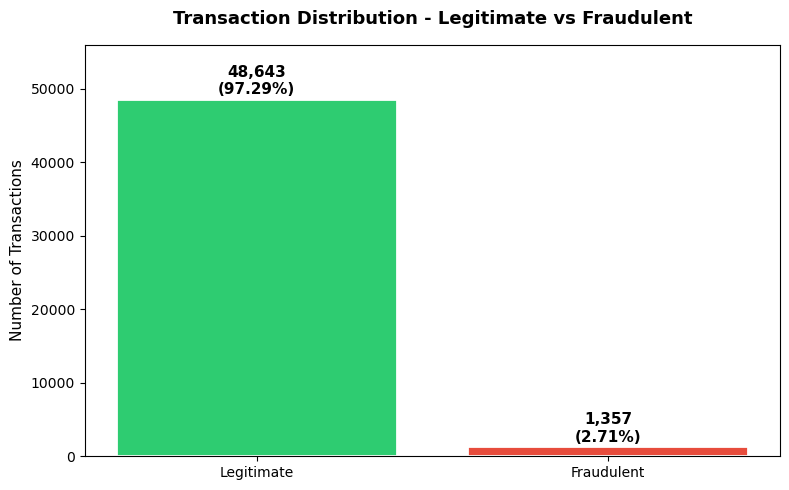

In [10]:
# To examine target variable.

print("Target Variable Distribution:")
print("="*40)
print (df['isFraud'].value_counts())
print(f"\nFraud Rate: {df['isFraud'].mean()*100:.3f}%")
print(f"Legitimate: {(1-df['isFraud'].mean())*100:.3f}%")
print(f"\nTotal Transactions: {len(df):,}")
print(f"Fraudulent: {df['isFraud'].sum():,}")
print(f"Legitimate: {(df['isFraud']==0).sum():,}")
print(df.head())
# Visualise

fig,ax = plt.subplots(figsize=(8,5))
counts = df['isFraud'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Legitimate','Fraudulent'], counts.values,
              color = colors,
              edgecolor = 'white',
              linewidth = 2)

ax.set_title('Transaction Distribution - Legitimate vs Fraudulent',
             fontsize = 13, fontweight = 'bold', pad = 15)
ax.set_ylabel('Number of Transactions', fontsize = 11)
ax.set_ylim(0,counts.max()*1.15)

for bar, count, pct in zip(bars, counts.values, [f'{v*100:.2f}%' for v in counts.values/len(df)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{count:,}\n({pct})', ha = 'center', va = 'bottom',
            fontsize = 11, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../data/fraud_distribution.png', dpi = 300, bbox_inches = 'tight')
plt.show()
    

### Step 2 - Data Profiling
434 columns across transaction and identity data. 

Question: What datatypes we have and how much is missing?

In [11]:
# Column type
print("Data types Summary:")
print(df.dtypes.value_counts())
print(f"\nTotal columns: {df.shape[1]}")

# Separate numeric and categorical
numeric_cols = df.select_dtypes(include = [np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include = ['object']).columns.tolist()
print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Missing Data Summary
missing = df.isnull().sum()
missing_pct = ((missing/len(df))*100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 
                           'missing_pct': missing_pct
                           }).query('missing_count>0').sort_values(
                               'missing_count', ascending=False)
print(f"\nColumns with missing data: {len(missing_df)}")
print(f"Columns >50% missing:  "f"{len(missing_df[missing_df['missing_pct']>50])}")
print(f"Columns >80% missing:  "f"{len(missing_df[missing_df['missing_pct']>80])}")
print(f"\n Top 10 most missing columns:")
print(missing_df.head(10).to_string())                                 

Data types Summary:
float64    399
object      31
int64        4
Name: count, dtype: int64

Total columns: 434

Numeric columns: 403
Categorical columns: 31

Columns with missing data: 359
Columns >50% missing:  232
Columns >80% missing:  25

 Top 10 most missing columns:
       missing_count  missing_pct
id_24          49441      98.9000
id_25          49402      98.8000
id_21          49396      98.8000
id_07          49393      98.8000
id_08          49393      98.8000
id_22          49392      98.8000
id_27          49392      98.8000
id_26          49392      98.8000
id_23          49392      98.8000
D7             47644      95.3000


### Step 3 - Missing Data Strategy
Three-tier approach based on fraud detection principle (using missing data as signal, not noise)

Tier 1 (>99% missing): Drop 
Tier 2 (50-99% missing): Binary indicator (1 = missing, 0 = present) ,then median/mode imputation
Tier 3 (<50% missing): Median/mode imputation only

NOTE: We preserve missingness patterns as features, as fraudsters exhibit systematic gaps in their digital footprint that legitimate customers don't.

In [12]:
# Calculate missing percentages
missing_pct = (df.isnull().sum(axis = 0)/len(df))*100

# Tier 1 - columns to drop (>99% missing)
tier1_drop = missing_pct[missing_pct > 99].index.tolist()

# Tier 2 - binary indicators (50-99% missing)
tier2_indicator = missing_pct[(missing_pct>=50) & (missing_pct <= 99)].index.tolist()

# Tier 3 - impute only (<50% missing)
tier3_impute = missing_pct[(missing_pct < 50) & (missing_pct > 0)].index.tolist()

print(f"Tier 1 - Drop:      {len(tier1_drop)}columns")
print(f"Tier 2 - Indicator: {len(tier2_indicator)}columns")
print(f"Tier 3 - Impute:    {len(tier3_impute)}columns")
print(f"No missing:         "f"{df.shape[1] - len(tier1_drop) - len(tier2_indicator) - len(tier3_impute)}columns")

# Create binary indicator feature for tier 2 columns
print(f"\nCreating binary indicators for Tier 2 columns...")
for col in tier2_indicator:
    df[f'{col}_missing'] = df[col].isnull().astype(int)
print(f"Binary indicator columns created: {len(tier2_indicator)}")
print(f"New data set shape: {df.shape}")

# Impute Tier 3 and Tier 2 columns
print(f"\nImputing missing values...")

# Numeric Columns - median
numeric_missing = [c for c in tier2_indicator + tier3_impute
                   if df[c].dtype != 'object']
for col in numeric_missing:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns - mode
cat_missing = [c for c in tier2_indicator + tier3_impute
               if df[c].dtype == 'object']
for col in cat_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

# Validate
remaining = df.isnull().sum().sum()
print(f"Missing values remaining: {remaining}")
print(f"Final dataset shape: {df.shape}")

Tier 1 - Drop:      0columns
Tier 2 - Indicator: 232columns
Tier 3 - Impute:    127columns
No missing:         75columns

Creating binary indicators for Tier 2 columns...
Binary indicator columns created: 232
New data set shape: (50000, 666)

Imputing missing values...
Missing values remaining: 0
Final dataset shape: (50000, 666)


### Step 4 - EDA: Business Question

1. What is the transaction amount distribution for fraud vs legitimate?
2. Which transaction types have highest fraud rate?
3. Does fraud cluster at specific times?
4. Which card types carry highest fraud rates?

Transaction Amount Statistics:
----------------------------------------
Metric                 Legitimate   Fraudulent
----------------------------------------
Mean                $     127.63$     145.79
Median               $      67.95$      81.97
Max                  $    4829.95$    3081.97
Std Dev              $     213.04$     213.67


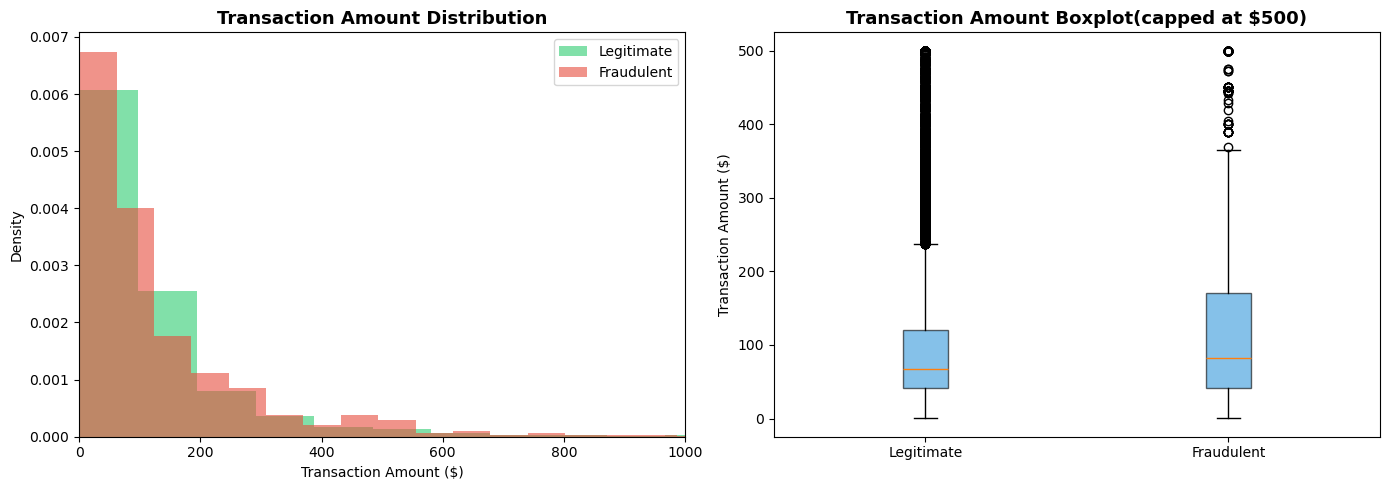

In [13]:
# Business Question 1 - Transaction Amount Distribution

fig,axes = plt.subplots(1,2, figsize=(14,5))

# Fraud vs Legitimate transaction amount
fraud = df[df['isFraud'] == 1]['TransactionAmt']
legit = df[df['isFraud'] == 0]['TransactionAmt']

axes[0].hist(legit, bins = 50, alpha = 0.6, color = '#2ecc71', label = 'Legitimate',density = True)
axes[0].hist(fraud, bins = 50, alpha = 0.6, color = '#e74c3c', label = 'Fraudulent',density = True)
axes[0].set_title('Transaction Amount Distribution', fontsize = 13, fontweight = 'bold')
axes[0].set_ylabel('Density')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Summary Statistics
print("Transaction Amount Statistics:")
print("-"*40)
print(f"{'Metric': <20} {'Legitimate': >12} {'Fraudulent': >12}")
print("-"*40)
print(f"{'Mean': <20}"
      f"${legit.mean():>11.2f}"
      f"${fraud.mean():>11.2f}")
print(f"{'Median': <20} "
      f"${legit.median():>11.2f}"
      f"${fraud.median():>11.2f}")
print(f"{'Max': <20} "
      f"${legit.max():>11.2f}"
      f"${fraud.max():>11.2f}")
print(f"{'Std Dev': <20} "
      f"${legit.std():>11.2f}"
      f"${fraud.std():>11.2f}")

# Box plot comparison
axes[1].boxplot([legit.clip(0,500),
                 fraud.clip(0,500)],
                 labels = ['Legitimate', 'Fraudulent'],
                 patch_artist = True,
                 boxprops = dict(facecolor = '#3498db', alpha = 0.6))
axes[1].set_title('Transaction Amount Boxplot'
                  '(capped at $500)',
                  fontsize = 13, fontweight = 'bold')
axes[1].set_ylabel('Transaction Amount ($)')
plt.tight_layout()
plt.savefig('../data/transaction_amount_dist.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**EDA Finding 1 - Transaction Amount**  
Contrary to the transaction-splitting hypothesis, fraudulent transactions are higher on average($145.79) than legitimate ones ($127.63).  
This suggests fraudsters in this dataset prioritise value extraction over stealth, consistent with CNP fraud where speed matters before card cancellation.  
'TransactionAmt' is a candidate model feature.

### Business Question 2 - Fraud Rate by Product Type  
Which channel carry the highest fraud concentration?  - ProductCD  indicates the transaction channel/product.

Fraud rate by ProductCD:
----------------------------------------
ProductCD  total  fraudulent  fraud_rate
        C   4934         497     10.0700
        R   3354          76      2.2700
        S   1464          29      1.9800
        W  32798         633      1.9300
        H   7450         122      1.6400


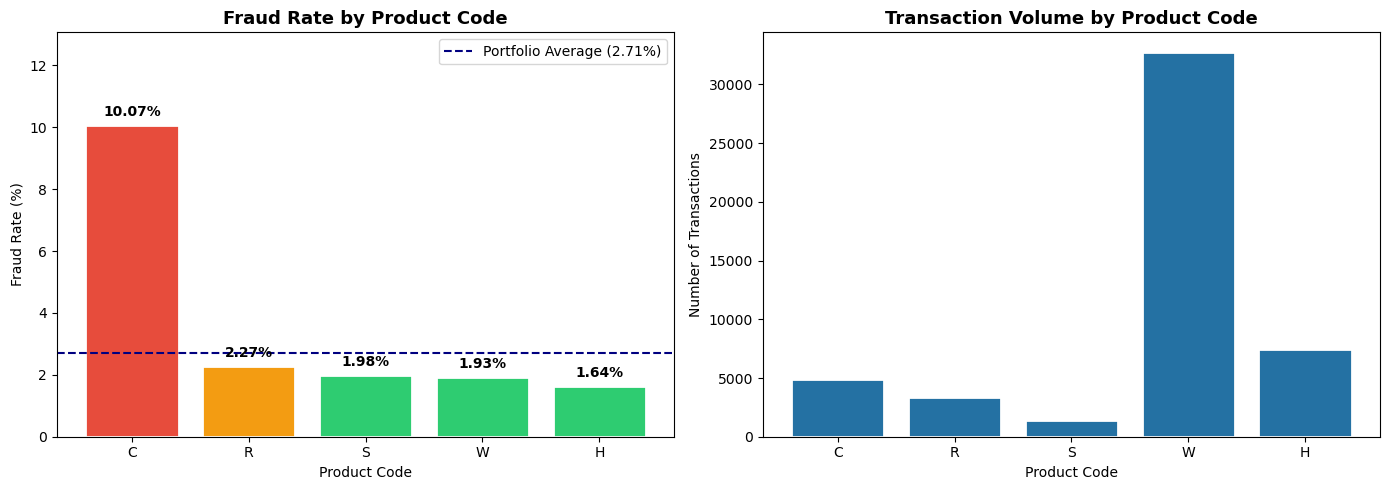

In [14]:
#Fraud rate by ProductCD
product_analysis = df.groupby('ProductCD')['isFraud'].agg(
    total = 'count', fraudulent = 'sum').reset_index()
product_analysis['fraud_rate'] = (product_analysis['fraudulent']/product_analysis['total']*100).round(2)
product_analysis = product_analysis.sort_values('fraud_rate', ascending = False)
print("Fraud rate by ProductCD:")
print("-"*40)
print(product_analysis.to_string(index = False))

# Visualise
fig, axes = plt.subplots(1,2, figsize = (14,5))

# Fraud rate
colors = ['#e74c3c' if r > 5 else'#f39c12'
          if r > 2 else '#2ecc71'
          for r in product_analysis['fraud_rate']]

bars = axes[0].bar(
    product_analysis['ProductCD'],
    product_analysis['fraud_rate'],
    color = colors, edgecolor = 'white', linewidth = 2
)
axes[0].set_title('Fraud Rate by Product Code', fontsize = 13, fontweight = 'bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Product Code')
axes[0].axhline(y = 2.71, color = 'navy', linestyle = '--', linewidth = 1.5, label = 'Portfolio Average (2.71%)')
axes[0].legend()
axes[0].set_ylim(0, product_analysis['fraud_rate'].max() + 3)

for bar, rate in zip(bars, product_analysis['fraud_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{rate}%', ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')

# Volume of transactions
axes[1].bar(product_analysis['ProductCD'], product_analysis['total'],
            color = '#2471a3', edgecolor = 'white', linewidth = 2)
axes[1].set_title('Transaction Volume by Product Code', fontsize = 13, fontweight = 'bold')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xlabel('Product Code')
plt.tight_layout()
plt.savefig('../data/fraud_by_product.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**EDA Finding 2 - Fraud by Product Code**  
ProductCD 'C'(credit/CNP transactions) carries 10.07% fraud rate : 3.7x the portfolio average of 2.71%. Despite representing only 10% of transaction volume, C-type transactions account for a disproportionate share of fraud cases. ProductCD is a high-value categorical feature for the model.  
ProductCD 'W' (web) dominates volume (65%) with near-average fraud rate (1.93%) - suggesting web channel control are effective. 

### Business Question 3 - Fraud Rate by Card Type  
card4 contains card network (Visa, Mastercard etc.)  
card6 contains card type (credit and debit)  

Which combination carry the highest fraud concentrations?

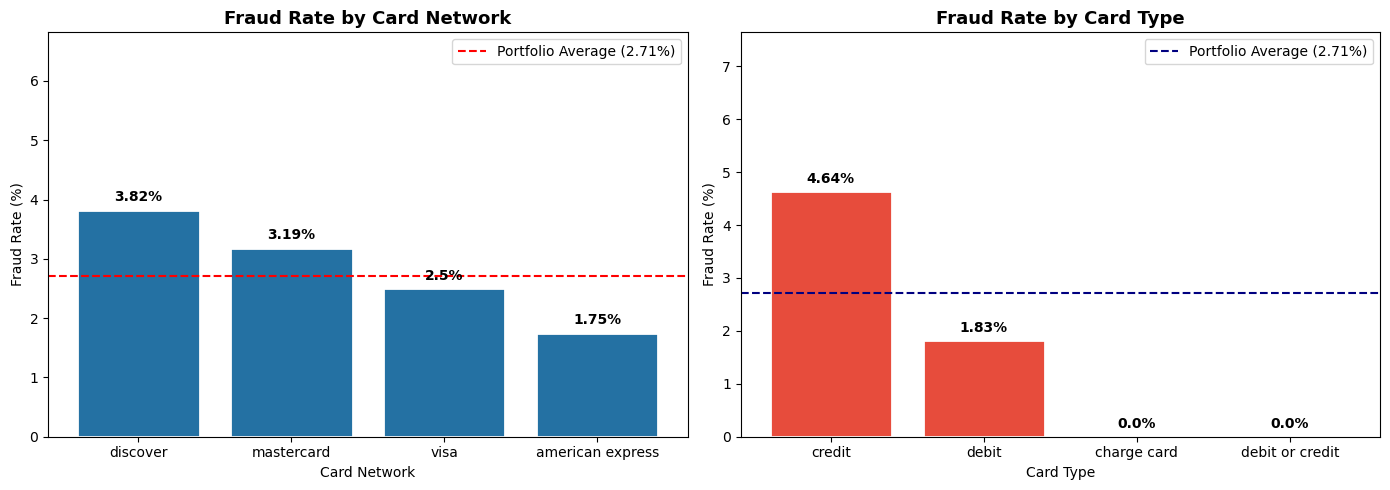

Card Network Analysis:
           card4  total  fraudulent  fraud_rate
        discover    654          25      3.8200
      mastercard  15696         500      3.1900
            visa  32567         813      2.5000
american express   1083          19      1.7500

Card Type Analysis:
          card6  total  fraudulent  fraud_rate
         credit  15786         732      4.6400
          debit  34208         625      1.8300
    charge card      3           0      0.0000
debit or credit      3           0      0.0000


In [15]:
# Fraud rate by card network - card4
fig, axes = plt.subplots(1,2,figsize = (14,5))

# card4 - card network
card4_analysis = df.groupby('card4')['isFraud'].agg(
    total = 'count', fraudulent = 'sum').reset_index()
card4_analysis['fraud_rate'] = (card4_analysis['fraudulent']/card4_analysis['total'] * 100).round(2)
card4_analysis = card4_analysis.sort_values(
    'fraud_rate', ascending = False
)
bars = axes[0].bar(card4_analysis['card4'], card4_analysis['fraud_rate'],
                   color = '#2471a3',
                   edgecolor = 'white', 
                   linewidth = 2)
axes[0].set_title('Fraud Rate by Card Network', fontsize = 13, fontweight = 'bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Card Network')
axes[0].axhline(y = 2.71, color = 'red', linestyle = '--', linewidth = 1.5, 
                label = 'Portfolio Average (2.71%)')
axes[0].legend()
axes[0].set_ylim(0, card4_analysis['fraud_rate'].max() + 3)

for bar, rate in zip(bars, card4_analysis['fraud_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{rate}%', ha = 'center', va = 'bottom', 
                 fontsize = 10, fontweight = 'bold')
    
# card6 - Credit vs Debit
card6_analysis = df.groupby('card6')['isFraud'].agg(
    total = 'count', fraudulent = 'sum'
).reset_index()
card6_analysis['fraud_rate'] = (card6_analysis['fraudulent']/card6_analysis['total'] * 100).round(2)
card6_analysis = card6_analysis.sort_values('fraud_rate', ascending = False)

bars2 = axes[1].bar(card6_analysis['card6'], card6_analysis['fraud_rate'], 
                    color = '#e74c3c', edgecolor = 'white', linewidth = 2)
axes[1].set_title('Fraud Rate by Card Type', fontsize = 13, fontweight = 'bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Card Type')
axes[1].axhline(y = 2.71, color = 'navy', linestyle = '--', linewidth = 1.5,
                label = 'Portfolio Average (2.71%)')
axes[1].legend()
axes[1].set_ylim(0, card6_analysis['fraud_rate'].max() + 3)

for bar, rate in zip(bars2, card6_analysis['fraud_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{rate}%', ha = 'center', va = 'bottom', 
                 fontsize = 10, fontweight = 'bold')
    
plt.tight_layout()
plt.savefig('../data/fraud_by_card.png', dpi = 300, bbox_inches = 'tight')
plt.show()

print("Card Network Analysis:")
print(card4_analysis.to_string(index = False))
print(f"\nCard Type Analysis:")
print(card6_analysis.to_string(index = False))

**EDA Finding 3 - Fraud by Card Network and Type**  
Discover carries the highest fraud rate(3.82%) despite having the lowest transaction volume - smaller acceptance network creates concentration risk.  
American Express lowest at 1.75% - reflecting premium customer base and fraud control.
  
Credit cards carry 4.64% fraud rate vs 1.83% for debit - 2.5x higher. Higher limits and delayed victim awareness make credit cards the preferred target for CNP fraud.
  
High-risk profile: CNP transaction + Discover + Credit Card

### Business Question 4 - Time-based Fraud Patterns  
TransactionDT is seconds elapsed from a reference point. Fraud often clusters at specific times - eg. late night when victims are asleep and less likely to notice unusula activity.

Key question: Does Fraud rate vary significantly by time of the day?

Fraud Rate by Hour of Day:
----------------------------------------
 transaction_hour  total  fraudulent  fraud_rate
                0   3294          91      2.7600
                1   2938          81      2.7600
                2   2376          56      2.3600
                3   1888          61      3.2300
                4   1326          37      2.7900
                5    956          37      3.8700
                6    570          24      4.2100
                7    350           8      2.2900
                8    211          13      6.1600
                9    203           9      4.4300
               10    212           6      2.8300
               11    407          13      3.1900
               12    845          23      2.7200
               13   1487          22      1.4800
               14   2322          41      1.7700
               15   2887          58      2.0100
               16   3500          83      2.3700
               17   3669          76      2.0700
 

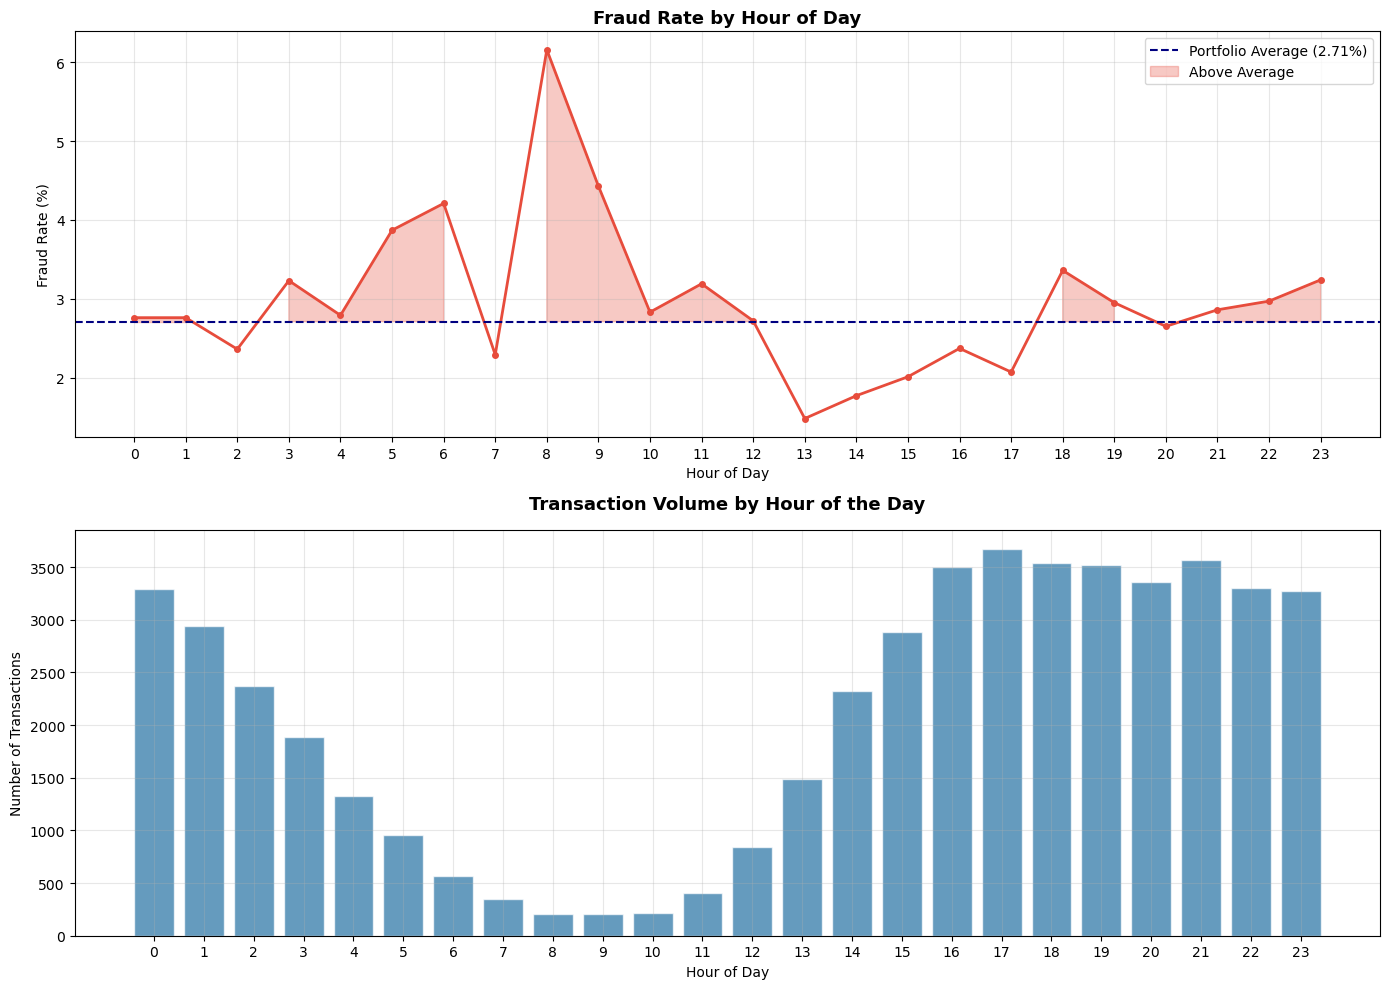

In [16]:
# TransactionDT is seconds from reference - convert to hours
# Reference point is unknown but relative patterns still valid
df['transaction_hour'] = (df['TransactionDT']//3600)%24

# Fraud rate by hour
hour_analysis = df.groupby('transaction_hour')['isFraud'].agg(
    total = 'count', fraudulent = 'sum'
).reset_index()
hour_analysis['fraud_rate'] = (hour_analysis['fraudulent']/hour_analysis['total']*100).round(2)
print("Fraud Rate by Hour of Day:")
print('-'*40)
print(hour_analysis.to_string(index = False))

# Visualise
fig, axes = plt.subplots(2,1,figsize = (14,10))

# Fraud rate by hour
axes[0].plot(hour_analysis['transaction_hour'], hour_analysis['fraud_rate'],
             color = '#e74c3c', linewidth = 2, marker = 'o', markersize = 4)
axes[0].axhline(y=2.71, color = 'navy', linestyle = '--', linewidth = 1.5,
                label = 'Portfolio Average (2.71%)')
axes[0].fill_between(hour_analysis['transaction_hour'], hour_analysis['fraud_rate'], 2.71,
                     where = hour_analysis['fraud_rate'] > 2.71, 
                     alpha = 0.3, color = '#e74c3c', label = 'Above Average')
axes[0].set_title('Fraud Rate by Hour of Day', fontsize = 13, fontweight = 'bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_xticks(range(0,24))
axes[0].legend()
axes[0].grid(alpha = 0.3)

# Transaction Volume by Hour
axes[1].bar(hour_analysis['transaction_hour'], hour_analysis['total'], color = '#2471a3',
            alpha = 0.7, edgecolor = 'white')
axes[1].set_title('Transaction Volume by Hour of the Day', 
                  fontsize = 13, fontweight = 'bold', pad = 15)
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xlabel('Hour of Day')
axes[1].set_xticks(range(0,24))
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig('../data/fraud_by_hour.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**EDA Finding 4 - Time-based Fraud Patterns**  
Fraud rate is elevated in early morning hours (3-6am) when victims are asleep - consistent with CNP fraud behaviour.  
Hours 7-10 show high apparent fraud rates but are statistically unreliable due to low transaction volume (<400 transactions).  
Transaction volume peaks 16-21 hours (afternoon/evening). Fraud volume are inversly correlated - fraud strikes when monitoring attention is lowest.  

NOTE: TransactionDT reference point is unknown - hour labels are relative, not absolute UTC time.